In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph


# define State
class AgentState(TypedDict):
    query: str
    context: str
    answer: str


graph_builder = StateGraph(AgentState)

In [4]:
# PromptTemplate 써도 되고 ChatPromptTemplate 써도 되고.
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal


class Route(BaseModel):
    target: Literal["income_tax", "llm", "real_estate_tax"] = Field(
        description="The target for the query to answer"
    )


router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to April 2026.
'real_estate_tax' contains information about real estate tax up to April 2026.
If you think the question is not related to either 'income_tax' or 'real_estate_tax'; you can use 'llm'
"""

router_prompt = ChatPromptTemplate.from_messages(
    [("system", router_system_prompt), ("user", "{query}")]
)


structured_router_llm = small_llm.with_structured_output(Route)


# expected answer : 'income_tax', 'real_estate_tax' or 'llm'
def router(state: AgentState):
    query = state["query"]
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({"query": query})
    print(f"router route == {route}")
    print(f"route.target == {route.target}")
    return route.target

In [5]:
from langchain_core.output_parsers import StrOutputParser


def call_llm(state: AgentState):
    query = state["query"]
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {"answer": llm_answer}

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node("income_tax", income_tax_agent)
graph_builder.add_node("real_estate_tax", real_estate_tax_agent)
graph_builder.add_node("llm", call_llm)

In [7]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {"income_tax": "income_tax", "real_estate_tax": "real_estate_tax", "llm": "llm"},
)
graph_builder.add_edge("income_tax", END)
graph_builder.add_edge("real_estate_tax", END)
graph_builder.add_edge("llm", END)

In [8]:
graph = graph_builder.compile()

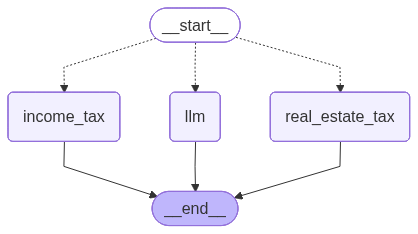

In [9]:
# get mermaid
graph

In [10]:
# test: 소득세

initial_state = {"query": "소득세란 무엇인가요?"}
graph.invoke(initial_state)

router route == target='income_tax'
route.target == income_tax


{'query': '소득세란 무엇인가요?',
 'context': [Document(id='8a4cf3b3-ddc4-44c6-8a1d-4ebdcd8acddf', metadata={'source': './income_tax.txt'}, page_content='소득세법\n\n소득세법\n\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21., 일부개정]\n\n재정경제부 (재산세제과(양도소득세)) 044-215-4312  \n재정경제부 (소득세제과(근로소득)) 044-215-4216  \n재정경제부 (금융세제과(이자소득, 배당소득)) 044-215-4233  \n재정경제부 (소득세제과(사업소득, 기타소득)) 044-215-4217  \n재정경제부 (국제조세제도과(비거주자)) 044-215-4651\n\n제1장 총칙 <개정 2009. 12. 31.>\n\n제1조(목적) 이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.  \n[본조신설 2009. 12. 31.]  \n[종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n\n제1조의2(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27., 2014. 12. 23., 2018. 12. 31.>  \n1. “거주자”란 국내에 주소를 두거나 183일 이상의 거소(居所)를 둔 개인을 말한다.  \n2. “비거주자”란 거주자가 아닌 개인을 말한다.  \n3. “내국법인”이란 「법인세법」 제2조제1호에 따른 내국법인을 말한다.  \n4. “외국법인”이란 「법인세법」 제2조제3호에 따른 외국법인을 말한다.  \n5. “사업자”란 사업소득이 있는 거주자를 말한다.  \n② 제1항에 따른 주소ㆍ거소와 거주자ㆍ비거주자의 구분은 대통령령으로 정한다.  \n[본조신설 2009. 12. 31.]'),
  Document(id='0678dfcc-2a67

In [11]:
# test: 종합부동산세
initial_state = {"query": "집 15억은 세금을 얼마나 내나요?"}

graph.invoke(initial_state)

router route == target='real_estate_tax'
route.target == real_estate_tax
context == {'query': '오늘 날짜:(2026-05-27)에 해당하는주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'As of 2026-05-27, the fair market value rate for housing property tax is 60%. This rate applies to both single-family homes and other properties. The rate is set to ensure equitable taxation based on market values.', 'images': ['https://on-estate.com/wp-content/uploads/2026/03/%EC%A0%9C%EB%AA%A9%EC%9D%84-%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94.-13-1024x724.jpg', 'https://www.joseilbo.com/gisa_img_origin/17768184131776818413_rozzhj_origin.png', 'https://drkjaf.com/wp-content/uploads/2026/03/featured-804-1024x559.jpg.webp', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://i.ytimg.com/vi/VN1Xukw3ICc/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAA

{'query': '집 15억은 세금을 얼마나 내나요?',
 'answer': '사용자가 소유한 주택이 1주택인지, 3주택 이상인지에 따라 세율이 달라집니다. 여기서는 제공된 정보를 바탕으로 두 경우를 나눠 계산하겠습니다.\n\n### 1. 1세대 1주택자인 경우\n- **과세표준:** 1.8억 원\n- **세율 적용:** \n  - 3억 원 이하 구간에 속하므로 1천분의 5를 적용.\n\n\\[ \\text{세금} = 1.8억 원 \\times \\frac{5}{1000} = 0.09 \\text{억 원} = 90만 원 \\]\n\n### 2. 1세대 1주택자가 아닌 경우 (2주택 이하)\n- **과세표준:** 3.6억 원\n- **세율 적용:**\n  - 3억 원 초과 6억 원 이하 구간에 속하므로 아래와 같이 계산.\n  - 기본 세액: 150만 원\n  - 초과 금액에 대한 추가 세금: (3.6억 원 - 3억 원) × 1천분의 7\n\n\\[ \\text{세금} = 150만 원 + (0.6억 원 \\times \\frac{7}{1000}) = 150만 원 + 42만 원 = 192만 원 \\]\n\n따라서:\n- 1세대 1주택자인 경우 세금은 90만 원입니다.\n- 1세대 1주택자가 아닌 경우 세금은 192만 원입니다.'}

In [12]:
# test: llm
initial_state = {"query": "여의도의 맛집은 어디인가요?"}

graph.invoke(initial_state)

router route == target='llm'
route.target == llm


{'query': '여의도의 맛집은 어디인가요?',
 'answer': '여의도에는 다양한 맛집이 많습니다. 아래는 몇 가지 추천할 만한 곳들입니다:\n\n1. **윤가** - 전통적인 한정식 집으로, 신선한 재료와 정갈한 반찬들이 인상적입니다.\n2. **안동찜닭** - 찜닭을 전문으로 하는 곳으로, 깊고 풍부한 맛이 매력적입니다.\n3. **히노키** - 일본식 스시와 사시미를 제공하는 고급스런 일식집입니다.\n4. **커피한약방** - 독특한 분위기와 함께 다양한 커피와 디저트를 즐길 수 있는 카페입니다.\n5. **홍대돈부리** - 푸짐한 돈부리 메뉴로 인기가 많은 식당입니다.\n\n각 식당의 운영시간과 예약 여부를 확인하고 가시는 것을 추천드립니다!'}